# LOADING LIBRARIES AND CONFIGURATION

In [107]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from prophet import Prophet
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
import locale
from matplotlib.ticker import FuncFormatter
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from datetime import datetime, timedelta
import calendar
import os
import json

class Config:
    """Configuration settings for the analysis"""
    DATA_URL = 'https://raw.githubusercontent.com/Vaishnavi1041/Data-Analytics-Internship-Project/main/Amazon%20Sale%20Report.csv'
    ENCODING = 'latin1'
    CURRENCY = 'INR'
    DATE_FORMATS = ['%m-%d-%y', '%d-%m-%y', '%Y-%m-%d']
    ZERO_AMOUNT_STATUSES = ["Cancelled", "On The Way", "Unshipped"]
    
config = Config()

# Enhanced locale setup
def setup_locale():
    """Setup locale with multiple fallback options"""
    locales_to_try = ['en_IN.UTF-8', 'en_IN', 'en_US.UTF-8', 'en_US', '']
    for loc in locales_to_try:
        try:
            locale.setlocale(locale.LC_ALL, loc)
            print(f"✓ Locale set to: {loc}")
            return True
        except locale.Error:
            continue
    print("⚠ Could not set Indian locale, using default")
    return False

setup_locale()

# Configuration
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Create directory for saving visuals
os.makedirs('sales_analysis_visuals', exist_ok=True)

print("✅ All libraries imported successfully")

# CORRECTED Indian Number Formatter
def format_indian(number):
    """Format numbers with Indian comma system - CORRECTED VERSION"""
    try:
        if pd.isna(number) or number == 0:
            return "₹0"
        
        number = float(number)
        # Handle negative numbers
        sign = "-" if number < 0 else ""
        number = abs(number)
        
        num_str = f"{number:.2f}"
        if '.' in num_str:
            int_part, dec_part = num_str.split('.')
        else:
            int_part, dec_part = num_str, "00"
        # Remove any existing commas
        int_part = int_part.replace(',', '')
        n = len(int_part)
        
        if n <= 3:
            result = int_part
        else:
            # Last 3 digits
            result = int_part[-3:]
            # Remaining digits
            remaining = int_part[:-3]
            # Process remaining digits in groups of 2 from right
            if len(remaining) > 0:
                if len(remaining) == 1:
                    result = remaining + ',' + result
                else:
                    # Add commas every 2 digits
                    formatted_remaining = ''
                    remaining_rev = remaining[::-1]  # Reverse for processing from right
                    for i in range(0, len(remaining_rev), 2):
                        formatted_remaining = remaining_rev[i:i+2] + ',' + formatted_remaining
                    result = formatted_remaining.rstrip(',') + ',' + result
        
        return f"{sign}₹{result}.{dec_part}" if dec_part != "00" else f"{sign}₹{result}"
    except Exception as e:
        # Fallback to standard formatting
        return f"₹{number:,.0f}"

def format_indian_int(number):
    """Format integers with Indian comma system - CORRECTED VERSION"""
    try:
        if pd.isna(number) or number == 0:
            return "0"
        
        number = int(number)
        num_str = str(number)
        n = len(num_str)
        
        if n <= 3:
            return num_str
        else:
            # Last 3 digits
            result = num_str[-3:]
            # Remaining digits
            remaining = num_str[:-3]
            # Process remaining digits in groups of 2 from right
            if len(remaining) > 0:
                if len(remaining) == 1:
                    result = remaining + ',' + result
                else:
                    # Add commas every 2 digits
                    formatted_remaining = ''
                    remaining_rev = remaining[::-1]  # Reverse for processing from right
                    for i in range(0, len(remaining_rev), 2):
                        formatted_remaining = remaining_rev[i:i+2] + ',' + formatted_remaining
                    result = formatted_remaining.rstrip(',') + ',' + result
            
            return result
    except:
        return str(number)

✓ Locale set to: en_IN.UTF-8
✅ All libraries imported successfully


# DATA COLLECTION AND CLEANING

In [108]:
def load_and_clean_data():
    """Load and clean the Amazon sales data"""
    print("📥 LOADING AND CLEANING DATA...")
    print("=" * 50)
    
    # Load the dataset
    try:
        df_raw = pd.read_csv(config.DATA_URL, encoding=config.ENCODING)
        df_raw.columns = df_raw.columns.str.strip()
        print(f"✅ Data loaded successfully: {df_raw.shape}")
    except Exception as e:
        print(f"❌ Error loading data: {e}")
        return None

    # Initial inspection
    print("\n📊 Raw Data Overview:")
    print(f"Dataset shape: {df_raw.shape}")
    print(f"Memory usage: {df_raw.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
    
    # Create a copy for cleaning
    df_clean = df_raw.copy()

    # Remove unnecessary columns
    columns_to_drop = ['Status', 'New', 'PendingS', 'index']
    df_clean = df_clean.drop([col for col in columns_to_drop if col in df_clean.columns], axis=1)

    # Remove duplicates
    initial_count = len(df_clean)
    df_clean = df_clean.drop_duplicates()
    print(f"✅ Removed {initial_count - len(df_clean)} duplicate rows")

    # Handle missing values
    fill_strategy = {
        'currency': 'INR',
        'ship-city': 'Unknown',
        'ship-state': 'Unknown',
        'ship-country': 'IN',
        'fulfilled-by': 'Unknown',
        'ship-postal-code': 0
    }

    for col, fill_val in fill_strategy.items():
        if col in df_clean.columns:
            df_clean[col].fillna(fill_val, inplace=True)

    # Standardize text columns
    text_columns = ['Category', 'Size', 'Fulfilment', 'Sales Channel', 'ship-state', 
                    'ship-city', 'ship-service-level', 'Courier Status', 'currency', 
                    'ship-country', 'fulfilled-by']

    for col in text_columns:
        if col in df_clean.columns:
            if col in ['Category', 'ship-state', 'ship-city']:
                df_clean[col] = df_clean[col].str.title().astype('string')
            elif col == 'Size':
                df_clean[col] = df_clean[col].str.upper().astype('string')
            else:
                df_clean[col] = df_clean[col].str.title().astype('string')

    # Convert Date and numeric columns
    def parse_dates_robust(df, date_column='Date'):
        """Parse dates with multiple possible formats"""
        date_formats = ['%m-%d-%y', '%d-%m-%y', '%Y-%m-%d', '%m/%d/%Y', '%d/%m/%Y']
        
        for fmt in date_formats:
            try:
                parsed_dates = pd.to_datetime(df[date_column], format=fmt, errors='coerce')
                success_rate = parsed_dates.notna().mean()
                if success_rate > 0.95:  # 95% success rate
                    df[date_column] = parsed_dates
                    print(f"✓ Dates parsed with format: {fmt} ({success_rate:.1%} success)")
                    return df
            except:
                continue
        
        # Final fallback
        df[date_column] = pd.to_datetime(df[date_column], errors='coerce')
        print("⚠ Used mixed format parsing as fallback")
        return df

    df_clean = parse_dates_robust(df_clean)
    df_clean['Amount'] = pd.to_numeric(df_clean['Amount'], errors='coerce').fillna(0).round(1)
    df_clean['Qty'] = pd.to_numeric(df_clean['Qty'], errors='coerce').fillna(0)
    df_clean['ship-postal-code'] = df_clean['ship-postal-code'].astype(int)

    # Business Logic Implementation for Zero Amounts
    statuses_zero_amount = ["Cancelled", "On The Way", "Unshipped"]
    df_clean.loc[(df_clean['Courier Status'].isin(statuses_zero_amount)) & 
                 (df_clean['Qty'] == 0), 'Amount'] = 0

    # Safe Unit Price Calculation
    df_clean['UnitPrice'] = np.where(df_clean['Qty'] > 0, 
                                    df_clean['Amount'] / df_clean['Qty'], 
                                    np.nan)

    # Intelligent Unit Price Imputation
    print("🔄 Applying hierarchical unit price imputation...")

    # First: Category + Size level average
    avg_price_category_size = (df_clean[df_clean['UnitPrice'].notna()]
                              .groupby(['Category', 'Size'])['UnitPrice']
                              .transform('mean'))
    # Second: Category level average
    avg_price_category = (df_clean[df_clean['UnitPrice'].notna()]
                         .groupby('Category')['UnitPrice']
                         .transform('mean'))

    # Third: Global median
    global_median = df_clean['UnitPrice'].median()

    # Apply imputation hierarchy
    df_clean['UnitPrice'] = (df_clean['UnitPrice']
                            .fillna(avg_price_category_size)
                            .fillna(avg_price_category)
                            .fillna(global_median))

    print("✅ Unit price imputation completed")

    # Fix Inconsistent Shipped/Unshipped Records
    mask_inconsistent = ((df_clean['Courier Status'].isin(['Shipped','Unshipped'])) & 
                        (df_clean['Amount'] == 0) & 
                        (df_clean['Qty'] > 0))

    if mask_inconsistent.any():
        print(f"🔄 Fixing {mask_inconsistent.sum()} inconsistent shipped records...")
        
        category_avg_prices = (df_clean[df_clean['UnitPrice'].notna()]
                              .groupby('Category')['UnitPrice']
                              .mean())
        
        df_clean.loc[mask_inconsistent, 'Amount'] = df_clean.loc[mask_inconsistent].apply(
            lambda row: row['Qty'] * category_avg_prices.get(row['Category'], global_median), 
            axis=1
        )
        print(f"✅ Fixed {mask_inconsistent.sum()} inconsistent shipped records")

    print("✅ Data cleaning completed successfully!")
    return df_clean

# DATA ENRICHMENT

In [109]:
def enrich_data(df):
    """Enrich data with additional features"""
    print("\n🎯 ENRICHING DATA WITH ADDITIONAL FEATURES...")
    print("=" * 50)
    
    df_enriched = df.copy()
    
    # Date Feature Engineering
    df_enriched['Date'] = pd.to_datetime(df_enriched['Date'])
    df_enriched['Month'] = df_enriched['Date'].dt.to_period('M')
    df_enriched['Week'] = df_enriched['Date'].dt.isocalendar().week
    df_enriched['DayOfWeek'] = df_enriched['Date'].dt.day_name()
    df_enriched['DayOfMonth'] = df_enriched['Date'].dt.day
    df_enriched['Quarter'] = df_enriched['Date'].dt.quarter
    df_enriched['YearMonth'] = df_enriched['Date'].dt.to_period('M').astype(str)

    # Seasonal Analysis
    df_enriched['Season'] = df_enriched['Date'].dt.month.map({
        12: 'Winter', 1: 'Winter', 2: 'Winter',
        3: 'Spring', 4: 'Spring', 5: 'Spring',
        6: 'Summer', 7: 'Summer', 8: 'Summer',
        9: 'Fall', 10: 'Fall', 11: 'Fall'
    })

    # Regional Mapping for India
    regional_mapping = {
        'North': ['Delhi', 'Uttar Pradesh', 'Punjab', 'Haryana', 'Himachal Pradesh', 'Uttarakhand', 'Chandigarh'],
        'South': ['Karnataka', 'Tamil Nadu', 'Kerala', 'Andhra Pradesh', 'Telangana', 'Puducherry'],
        'East': ['West Bengal', 'Odisha', 'Bihar', 'Jharkhand', 'Assam', 'Tripura'],
        'West': ['Maharashtra', 'Gujarat', 'Rajasthan', 'Goa'],
        'Central': ['Madhya Pradesh', 'Chhattisgarh']
    }

    def get_region(state):
        for region, states in regional_mapping.items():
            if state in states:
                return region
        return 'Other'

    df_enriched['Region'] = df_enriched['ship-state'].apply(get_region)

    print("✅ Data enrichment completed")
    return df_enriched


# SALES ANALYSIS

In [110]:
def analyze_sales_performance(df):
    """Comprehensive sales performance analysis"""
    print("\n💰 SALES PERFORMANCE ANALYSIS")
    print("=" * 50)
    
    # Calculate KPIs
    total_revenue = df['Amount'].sum()
    total_orders = len(df)
    total_quantity = df['Qty'].sum()
    avg_order_value = df['Amount'].mean()
    unique_products = df['Category'].nunique()
    unique_customers = df['ship-city'].nunique()
    unique_states = df['ship-state'].nunique()
    
    # Daily metrics
    daily_revenue = df.groupby('Date')['Amount'].sum()
    avg_daily_revenue = daily_revenue.mean()
    peak_daily_revenue = daily_revenue.max()
    
    # Top performers
    top_category = df['Category'].value_counts().index[0]
    top_state = df['ship-state'].value_counts().index[0]
    
    # Conversion and cancellation rates
    shipped_orders = (df['Courier Status'] == 'Shipped').sum()
    conversion_rate = shipped_orders / total_orders
    cancelled_orders = (df['Courier Status'] == 'Cancelled').sum()
    cancellation_rate = cancelled_orders / total_orders
    
    kpis = {
        'total_revenue': total_revenue,
        'total_orders': total_orders,
        'total_quantity': total_quantity,
        'avg_order_value': avg_order_value,
        'unique_products': unique_products,
        'unique_customers': unique_customers,
        'unique_states': unique_states,
        'avg_daily_revenue': avg_daily_revenue,
        'peak_daily_revenue': peak_daily_revenue,
        'top_category': top_category,
        'top_state': top_state,
        'conversion_rate': conversion_rate,
        'cancellation_rate': cancellation_rate
    }
    
    # Print KPIs
    print("🎯 Financial Metrics:")
    print(f"  Total Revenue: {format_indian(kpis['total_revenue'])}")
    print(f"  Average Order Value: {format_indian(kpis['avg_order_value'])}")
    print(f"  Average Daily Revenue: {format_indian(kpis['avg_daily_revenue'])}")
    print(f"  Peak Daily Revenue: {format_indian(kpis['peak_daily_revenue'])}")

    print("\n🎯 Volume Metrics:")
    print(f"  Total Orders: {format_indian_int(kpis['total_orders'])}")
    print(f"  Total Quantity Sold: {format_indian_int(kpis['total_quantity'])}")
    print(f"  Unique Products: {format_indian_int(kpis['unique_products'])}")

    print("\n🎯 Customer Metrics:")
    print(f"  Unique Customer Cities: {format_indian_int(kpis['unique_customers'])}")
    print(f"  States Served: {format_indian_int(kpis['unique_states'])}")
    print(f"  Conversion Rate: {kpis['conversion_rate']:.1%}")
    print(f"  Cancellation Rate: {kpis['cancellation_rate']:.1%}")

    print("\n🎯 Top Performers:")
    print(f"  Top Category: {kpis['top_category']}")
    print(f"  Top State: {kpis['top_state']}")
    
    return kpis

# PRODUCT ANALYSIS

In [111]:
def analyze_product_performance(df):
    """Comprehensive product performance analysis"""
    print("\n🛍️ PRODUCT PERFORMANCE ANALYSIS")
    print("=" * 50)
    
    # Category Performance
    category_performance = df.groupby('Category').agg({
        'Amount': ['sum', 'mean', 'count'],
        'Qty': 'sum',
        'UnitPrice': 'mean'
    }).round(2)
    
    category_performance.columns = ['Total_Revenue', 'Avg_Order_Value', 'Order_Count', 'Total_Quantity', 'Avg_Unit_Price']
    category_performance = category_performance.sort_values('Total_Revenue', ascending=False)
    
    # Add revenue share percentage
    total_revenue = df['Amount'].sum()
    category_performance['Revenue_Share'] = (category_performance['Total_Revenue'] / total_revenue * 100).round(2)
    
    print("📊 Top Categories by Revenue:")
    for idx, (category, row) in enumerate(category_performance.head(10).iterrows(), 1):
        print(f"  {idx}. {category}: {format_indian(row['Total_Revenue'])} "
              f"({format_indian_int(row['Order_Count'])} orders)")

    # Size Analysis
    print("\n📏 SIZE DISTRIBUTION ANALYSIS:")
    size_analysis = df.groupby('Size').agg({
        'Amount': 'sum',
        'Qty': 'sum',
        'Order ID': 'count'
    }).sort_values('Amount', ascending=False)
    
    size_analysis.columns = ['Total_Revenue', 'Total_Quantity', 'Order_Count']
    
    print("Most Popular Sizes:")
    for size, row in size_analysis.head(10).iterrows():
        print(f"  Size {size}: {format_indian_int(row['Total_Quantity'])} units, "
              f"{format_indian(row['Total_Revenue'])} revenue")
    
    return {
        'category_performance': category_performance,
        'size_analysis': size_analysis
    }

# FULFILLMENT ANALYSIS

In [112]:
def analyze_fulfillment_performance(df):
    """Fulfillment and shipping performance analysis"""
    print("\n🚚 FULFILLMENT PERFORMANCE ANALYSIS")
    print("=" * 50)
    
    # Fulfillment Method Performance
    fulfillment_performance = df.groupby('Fulfilment').agg({
        'Order ID': 'count',
        'Amount': ['sum', 'mean'],
        'Qty': 'sum',
        'Courier Status': lambda x: (x == 'Shipped').mean() * 100  # Success rate
    }).round(2)

    fulfillment_performance.columns = ['Order_Count', 'Total_Revenue', 'Avg_Order_Value', 'Total_Quantity', 'Success_Rate']

    print("📦 FULFILLMENT METHOD COMPARISON:")
    for fulfillment, row in fulfillment_performance.iterrows():
        print(f"  {fulfillment}:")
        print(f"    • Orders: {format_indian_int(row['Order_Count'])}")
        print(f"    • Revenue: {format_indian(row['Total_Revenue'])}")
        print(f"    • Success Rate: {row['Success_Rate']:.1f}%")
        print(f"    • Avg Order Value: {format_indian(row['Avg_Order_Value'])}")

    # Shipping Service Level Analysis
    print("\n🚛 SHIPPING SERVICE LEVEL PERFORMANCE:")
    shipping_analysis = df.groupby('ship-service-level').agg({
        'Order ID': 'count',
        'Amount': 'sum',
        'Courier Status': lambda x: (x == 'Shipped').mean() * 100
    }).round(2)

    for service, row in shipping_analysis.iterrows():
        print(f"  {service}: {format_indian_int(row['Order ID'])} orders, "
              f"{row['Courier Status']:.1f}% success rate")

    # Courier Status Distribution
    print("\n📮 ORDER STATUS DISTRIBUTION:")
    status_distribution = df['Courier Status'].value_counts()
    for status, count in status_distribution.items():
        percentage = (count / len(df)) * 100
        print(f"  {status}: {format_indian_int(count)} orders ({percentage:.1f}%)")
    
    return fulfillment_performance

# CUSTOMER SEGMENTATION

In [113]:
def analyze_customer_segments(df):
    """Customer segmentation and RFM analysis"""
    print("\n👥 CUSTOMER SEGMENTATION ANALYSIS")
    print("=" * 50)
    
    # RFM Analysis by City
    print("🎯 RFM ANALYSIS (Recency, Frequency, Monetary):")

    # Calculate RFM metrics
    latest_date = df['Date'].max()
    rfm_data = df.groupby('ship-city').agg({
        'Date': lambda x: (latest_date - x.max()).days,  # Recency
        'Order ID': 'count',                            # Frequency
        'Amount': 'sum',                                # Monetary
        'Qty': 'sum'
    }).rename(columns={
        'Date': 'Recency_Days',
        'Order ID': 'Frequency',
        'Amount': 'Monetary_Value',
        'Qty': 'Total_Units'
    }).round(2)

    # Remove "Unknown" cities
    rfm_data = rfm_data[rfm_data.index != 'Unknown']

    print("\n🏆 TOP 10 CUSTOMER CITIES BY REVENUE:")
    top_cities = rfm_data.nlargest(10, 'Monetary_Value')
    for idx, (city, row) in enumerate(top_cities.iterrows(), 1):
        print(f"  {idx}. {city}: {format_indian(row['Monetary_Value'])} "
              f"({row['Frequency']} orders, {format_indian_int(row['Total_Units'])} units)")

    # Customer Value Segments
    print("\n💰 CUSTOMER VALUE SEGMENTATION:")
    rfm_data['Customer_Value'] = rfm_data['Monetary_Value']
    value_segments = pd.cut(rfm_data['Customer_Value'], 
                           bins=[0, 10000, 50000, 200000, float('inf')],
                           labels=['Bronze', 'Silver', 'Gold', 'Platinum'])

    segment_counts = value_segments.value_counts()
    print("Customer Value Distribution:")
    for segment, count in segment_counts.items():
        print(f"  {segment}: {count} cities")

    # High-Value Customer Insights
    platinum_cities = rfm_data[value_segments == 'Platinum']
    print(f"\n🎯 PLATINUM CUSTOMER CITIES ({len(platinum_cities)} cities):")
    for city in platinum_cities.nlargest(5, 'Monetary_Value').index:
        data = platinum_cities.loc[city]
        print(f"  • {city}: {format_indian(data['Monetary_Value'])}, "
              f"{data['Frequency']} orders, Recency: {data['Recency_Days']} days")
    
    return rfm_data


# GEOGRAPHICAL ANALYSIS

In [114]:
def analyze_geographical_performance(df):
    """Geographical distribution analysis"""
    print("\n🗺️ GEOGRAPHICAL PERFORMANCE ANALYSIS")
    print("=" * 50)
    
    # Regional Performance
    print("🌍 REGIONAL PERFORMANCE:")
    region_performance = df.groupby('Region').agg({
        'Amount': ['sum', 'mean', 'count'],
        'Qty': 'sum',
        'UnitPrice': 'mean'
    }).round(2)

    region_performance.columns = ['Total_Revenue', 'Avg_Order_Value', 'Order_Count', 'Total_Quantity', 'Avg_Unit_Price']
    region_performance = region_performance.sort_values('Total_Revenue', ascending=False)

    total_revenue = df['Amount'].sum()
    
    for region, row in region_performance.iterrows():
        print(f"  {region}:")
        print(f"    • Revenue: {format_indian(row['Total_Revenue'])}")
        print(f"    • Orders: {format_indian_int(row['Order_Count'])}")
        print(f"    • Avg Order Value: {format_indian(row['Avg_Order_Value'])}")
        print(f"    • Market Share: {(row['Total_Revenue'] / total_revenue * 100):.1f}%")

    # State Performance
    print("\n🏛️ TOP 10 STATES BY REVENUE:")
    state_performance = df.groupby('ship-state').agg({
        'Amount': 'sum',
        'Order ID': 'count',
        'Qty': 'sum',
        'UnitPrice': 'mean'
    }).round(2).sort_values('Amount', ascending=False)

    state_performance = state_performance[state_performance.index != 'Unknown']

    for idx, (state, row) in enumerate(state_performance.head(10).iterrows(), 1):
        print(f"  {idx}. {state}: {format_indian(row['Amount'])} "
              f"({format_indian_int(row['Order ID'])} orders)")
    
    return {
        'region_performance': region_performance,
        'state_performance': state_performance
    }

# VISUALIZATION

In [115]:
def create_sales_trend_visualizations(df):
    """Create and save sales trend visualizations"""
    print("\n📈 CREATING SALES TREND VISUALIZATIONS...")
    
    # Monthly Revenue Trend
    plt.figure(figsize=(14, 8))
    monthly_revenue = df.groupby(df['Date'].dt.to_period('M'))['Amount'].sum()
    plt.plot(monthly_revenue.index.astype(str), monthly_revenue.values, 
             marker='o', linewidth=3, color='#2E86AB', markersize=8)
    plt.title('📈 Monthly Revenue Trend', fontsize=16, fontweight='bold', pad=20)
    plt.ylabel('Revenue (₹)', fontsize=12)
    plt.xlabel('Month', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig('sales_analysis_visuals/monthly_revenue_trend.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Daily Sales Distribution
    plt.figure(figsize=(12, 6))
    daily_sales = df.groupby('Date')['Amount'].sum()
    plt.hist(daily_sales, bins=30, color='#A23B72', alpha=0.7, edgecolor='black')
    plt.title('📊 Daily Sales Distribution', fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Daily Revenue (₹)', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('sales_analysis_visuals/daily_sales_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✅ Sales trend visualizations saved!")

def create_category_visualizations(df, category_performance):
    """Create and save category performance visualizations"""
    print("🛍️ CREATING CATEGORY PERFORMANCE VISUALIZATIONS...")
    
    # Top Categories Bar Chart
    plt.figure(figsize=(14, 8))
    top_categories = category_performance.head(10)
    colors = plt.cm.Set3(np.arange(len(top_categories)))
    
    bars = plt.bar(range(len(top_categories)), top_categories['Total_Revenue'], color=colors)
    plt.title('🏆 Top 10 Categories by Revenue', fontsize=16, fontweight='bold', pad=20)
    plt.ylabel('Revenue (₹)', fontsize=12)
    plt.xlabel('Category', fontsize=12)
    plt.xticks(range(len(top_categories)), top_categories.index, rotation=45, ha='right')
    
    # Add value labels on bars
    for i, bar in enumerate(bars):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'₹{height:,.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('sales_analysis_visuals/top_categories.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Category Revenue Distribution (Pie Chart)
    plt.figure(figsize=(12, 8))
    top_8_categories = category_performance.head(8)
    plt.pie(top_8_categories['Total_Revenue'], labels=top_8_categories.index, 
            autopct='%1.1f%%', startangle=90, colors=plt.cm.Pastel1(np.arange(8)))
    plt.title('📊 Category Revenue Distribution', fontsize=16, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.savefig('sales_analysis_visuals/category_revenue_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✅ Category visualizations saved!")

def create_regional_visualizations(region_performance):
    """Create and save regional performance visualizations"""
    print("🗺️ CREATING REGIONAL VISUALIZATIONS...")
    
    # Regional Revenue Distribution
    plt.figure(figsize=(12, 8))
    plt.pie(region_performance['Total_Revenue'], labels=region_performance.index, 
            autopct='%1.1f%%', startangle=90, colors=plt.cm.Set3(np.arange(len(region_performance))))
    plt.title('🌍 Revenue Distribution by Region', fontsize=16, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.savefig('sales_analysis_visuals/regional_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Regional Performance Bar Chart
    plt.figure(figsize=(12, 6))
    region_performance_sorted = region_performance.sort_values('Total_Revenue', ascending=False)
    bars = plt.bar(region_performance_sorted.index, region_performance_sorted['Total_Revenue'],
                  color=plt.cm.Blues(np.linspace(0.4, 0.8, len(region_performance_sorted))))
    plt.title('💰 Revenue by Region', fontsize=16, fontweight='bold', pad=20)
    plt.ylabel('Revenue (₹)', fontsize=12)
    plt.xticks(rotation=45)
    
    # Add value labels
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'₹{height:,.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('sales_analysis_visuals/regional_revenue_bars.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✅ Regional visualizations saved!")

def create_fulfillment_visualizations(fulfillment_performance, df):
    """Create and save fulfillment performance visualizations"""
    print("🚚 CREATING FULFILLMENT VISUALIZATIONS...")
    
    # Fulfillment Method Comparison
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Revenue by fulfillment
    fulfillment_performance_sorted = fulfillment_performance.sort_values('Total_Revenue', ascending=False)
    bars1 = ax1.bar(fulfillment_performance_sorted.index, fulfillment_performance_sorted['Total_Revenue'],
                   color=['#FF6B6B', '#4ECDC4'])
    ax1.set_title('💰 Revenue by Fulfillment Method', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Revenue (₹)')
    
    # Add value labels
    for i, bar in enumerate(bars1):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 1000000,
                f'{format_indian(height)}', ha='center', va='bottom', fontsize=10)
    
    # Success rate
    ax2.bar(fulfillment_performance_sorted.index, fulfillment_performance_sorted['Success_Rate'],
           color=['#45B7D1', '#96CE45'])
    ax2.set_title('✅ Fulfillment Success Rate', fontsize=14, fontweight='bold')
    ax2.set_ylabel('Success Rate (%)')
    ax2.set_ylim(0, 100)
    
    # Add value labels
    for i, v in enumerate(fulfillment_performance_sorted['Success_Rate']):
        ax2.text(i, v + 1, f'{v:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('sales_analysis_visuals/fulfillment_performance.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Courier Status Distribution
    plt.figure(figsize=(10, 8))
    courier_status = df['Courier Status'].value_counts()
    colors = plt.cm.viridis(np.linspace(0, 1, len(courier_status)))
    
    wedges, texts, autotexts = plt.pie(courier_status.values, labels=courier_status.index, 
                                      autopct='%1.1f%%', colors=colors, startangle=90)
    
    plt.title('📦 Distribution of Courier Status', fontsize=16, fontweight='bold', pad=20)
    
    # Make autotexts more readable
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontweight('bold')
        autotext.set_fontsize(10)
    
    plt.tight_layout()
    plt.savefig('sales_analysis_visuals/courier_status_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✅ Fulfillment visualizations saved!")

def create_seasonal_visualizations(df):
    """Create and save seasonal analysis visualizations"""
    print("🌤️ CREATING SEASONAL VISUALIZATIONS...")
    
    # Seasonal Sales Pattern
    plt.figure(figsize=(12, 6))
    seasonal_sales = df.groupby('Season')['Amount'].sum()
    season_order = ['Winter', 'Spring', 'Summer', 'Fall']
    seasonal_sales = seasonal_sales.reindex(season_order)
    
    bars = plt.bar(seasonal_sales.index, seasonal_sales.values, 
                  color=['#1E90FF', '#32CD32', '#FFD700', '#FF6347'])
    plt.title('📅 Seasonal Sales Pattern', fontsize=16, fontweight='bold', pad=20)
    plt.ylabel('Revenue (₹)', fontsize=12)
    
    # Add value labels
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'₹{height:,.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('sales_analysis_visuals/seasonal_sales.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✅ Seasonal visualizations saved!")

def create_comprehensive_dashboard(df, category_performance, region_performance, fulfillment_performance):
    """Create a comprehensive dashboard visualization"""
    print("📊 CREATING COMPREHENSIVE DASHBOARD...")
    
    fig = plt.figure(figsize=(25, 20))
    fig.suptitle('AMAZON SALES PERFORMANCE DASHBOARD', fontsize=24, fontweight='bold', y=0.98)
    
    # 1. Monthly Revenue Trend (Top Left)
    ax1 = plt.subplot2grid((4, 4), (0, 0), colspan=2)
    monthly_revenue = df.groupby(df['Date'].dt.to_period('M'))['Amount'].sum()
    ax1.plot(monthly_revenue.index.astype(str), monthly_revenue.values, 
             marker='o', linewidth=2, color='#2E86AB')
    ax1.set_title('📈 Monthly Revenue Trend', fontsize=16, fontweight='bold', pad=20)
    ax1.set_ylabel('Revenue (₹)', fontsize=12)
    ax1.grid(True, alpha=0.3)
    ax1.tick_params(axis='x', rotation=45)
    
    # 2. Top Categories (Top Right)
    ax2 = plt.subplot2grid((4, 4), (0, 2), colspan=2)
    top_categories = category_performance.head(8)
    bars = ax2.bar(range(len(top_categories)), top_categories['Total_Revenue'], 
                  color=plt.cm.Set3(np.arange(len(top_categories))))
    ax2.set_title('🏆 Top Product Categories', fontsize=16, fontweight='bold', pad=20)
    ax2.set_ylabel('Revenue (₹)', fontsize=12)
    ax2.set_xticks(range(len(top_categories)))
    ax2.set_xticklabels(top_categories.index, rotation=45, ha='right')
    
    # 3. Regional Distribution (Second Row Left)
    ax3 = plt.subplot2grid((4, 4), (1, 0), colspan=2)
    ax3.pie(region_performance['Total_Revenue'], labels=region_performance.index, 
           autopct='%1.1f%%', startangle=90, colors=plt.cm.Pastel1(np.arange(len(region_performance))))
    ax3.set_title('🗺️ Revenue by Region', fontsize=16, fontweight='bold', pad=20)
    
    # 4. Fulfillment Performance (Second Row Right)
    ax4 = plt.subplot2grid((4, 4), (1, 2), colspan=2)
    fulfillment_data = fulfillment_performance[['Total_Revenue', 'Success_Rate']]
    x = range(len(fulfillment_data))
    width = 0.35

    bars1 = ax4.bar(x, fulfillment_data['Total_Revenue'], width, label='Revenue', color='#A23B72', alpha=0.7)
    ax4_twin = ax4.twinx()
    bars2 = ax4_twin.bar([i + width for i in x], fulfillment_data['Success_Rate'], width, 
                        label='Success Rate %', color='#F18F01', alpha=0.7)

    ax4.set_title('🚚 Fulfillment Performance', fontsize=16, fontweight='bold', pad=20)
    ax4.set_ylabel('Revenue (₹)', fontsize=12)
    ax4_twin.set_ylabel('Success Rate (%)', fontsize=12)
    ax4.set_xticks([i + width/2 for i in x])
    ax4.set_xticklabels(fulfillment_data.index)
    ax4.legend(loc='upper left')
    ax4_twin.legend(loc='upper right')
    
    # 5. Seasonal Pattern (Third Row Left)
    ax5 = plt.subplot2grid((4, 4), (2, 0), colspan=2)
    seasonal_sales = df.groupby('Season')['Amount'].sum()
    season_order = ['Winter', 'Spring', 'Summer', 'Fall']
    seasonal_sales = seasonal_sales.reindex(season_order)
    ax5.bar(seasonal_sales.index, seasonal_sales.values, color=['#1E90FF', '#32CD32', '#FFD700', '#FF6347'])
    ax5.set_title('🌤️ Seasonal Sales Pattern', fontsize=16, fontweight='bold', pad=20)
    ax5.set_ylabel('Revenue (₹)', fontsize=12)
    
    # 6. Size Performance (Third Row Right)
    ax6 = plt.subplot2grid((4, 4), (2, 2), colspan=2)
    size_performance = df.groupby('Size')['Amount'].sum().sort_values(ascending=False).head(8)
    ax6.bar(range(len(size_performance)), size_performance.values, color='#20B2AA')
    ax6.set_title('📦 Revenue by Product Size', fontsize=16, fontweight='bold', pad=20)
    ax6.set_ylabel('Revenue (₹)', fontsize=12)
    ax6.set_xticks(range(len(size_performance)))
    ax6.set_xticklabels(size_performance.index, rotation=45)
    
    # 7. Order Status Distribution (Fourth Row Left)
    ax7 = plt.subplot2grid((4, 4), (3, 0))
    status_dist = df['Courier Status'].value_counts()
    colors = ['#4CAF50', '#FF9800', '#F44336', '#9C27B0']
    ax7.pie(status_dist.values, labels=status_dist.index, autopct='%1.1f%%',
           startangle=90, colors=colors[:len(status_dist)])
    ax7.set_title('📊 Order Status Distribution', fontsize=16, fontweight='bold', pad=20)
    
    # 8. Customer Value Segments (Fourth Row Middle)
    ax8 = plt.subplot2grid((4, 4), (3, 1))
    order_values = df.groupby('Order ID')['Amount'].sum()
    high_value = (order_values > 1000).sum()
    medium_value = ((order_values > 500) & (order_values <= 1000)).sum()
    low_value = (order_values <= 500).sum()

    segments = [high_value, medium_value, low_value]
    segment_labels = ['High Value\n(>₹1000)', 'Medium Value\n(₹500-1000)', 'Low Value\n(≤₹500)']
    
    ax8.pie(segments, labels=segment_labels, autopct='%1.1f%%', startangle=90)
    ax8.set_title('💎 Customer Value Segments', fontsize=16, fontweight='bold', pad=20)
    
    # 9. B2B vs B2C Performance (Fourth Row Right)
    ax9 = plt.subplot2grid((4, 4), (3, 2))
    b2b_performance = df.groupby('B2B').agg({'Amount': 'sum'}).round(2)
    b2b_performance.index = ['B2C', 'B2B']
    ax9.bar(b2b_performance.index, b2b_performance['Amount'], color=['#FFA07A', '#87CEEB'], alpha=0.8)
    ax9.set_title('🏢 B2B vs B2C Revenue', fontsize=16, fontweight='bold', pad=20)
    ax9.set_ylabel('Revenue (₹)', fontsize=12)
    
    # 10. Price Range Analysis (Fourth Row Far Right)
    ax10 = plt.subplot2grid((4, 4), (3, 3))
    price_ranges = pd.cut(df['UnitPrice'], bins=[0, 300, 600, 1000, float('inf')], 
                         labels=['Budget\n(<₹300)', 'Mid-Range\n(₹300-600)', 'Premium\n(₹600-1000)', 'Luxury\n(₹1000+)'])
    price_analysis = df.groupby(price_ranges)['Amount'].sum()
    ax10.pie(price_analysis.values, labels=price_analysis.index, autopct='%1.1f%%', startangle=90)
    ax10.set_title('💰 Price Range Performance', fontsize=16, fontweight='bold', pad=20)
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.95, hspace=0.4, wspace=0.3)
    plt.savefig('sales_analysis_visuals/comprehensive_dashboard.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✅ Comprehensive dashboard saved!")

# EXECUTIVE REPORT GENERATION

In [116]:
def generate_executive_report(df, sales_kpis, product_analysis, customer_analysis, geo_analysis):
    """Generate comprehensive executive report"""
    print("\n📋 GENERATING EXECUTIVE REPORT...")
    print("=" * 50)
    
    total_revenue = sales_kpis['total_revenue']
    total_orders = sales_kpis['total_orders']
    
    # Executive Summary
    print("\n🎯 EXECUTIVE SUMMARY")
    print("=" * 50)
    print(f"Analysis Period: {df['Date'].min().strftime('%Y-%m-%d')} to {df['Date'].max().strftime('%Y-%m-%d')}")
    print(f"Total Revenue: {format_indian(total_revenue)}")
    print(f"Total Orders: {format_indian_int(total_orders)}")
    print(f"Average Order Value: {format_indian(sales_kpis['avg_order_value'])}")
    print(f"Customer Reach: {sales_kpis['unique_customers']} cities across {sales_kpis['unique_states']} states")
    print(f"Order Success Rate: {sales_kpis['conversion_rate']:.1%}")
    
    # Key Insights
    print("\n💡 KEY INSIGHTS")
    print("=" * 50)
    
    # Top performing categories
    top_category = product_analysis['category_performance'].index[0]
    top_category_revenue = product_analysis['category_performance'].iloc[0]['Total_Revenue']
    category_share = (top_category_revenue / total_revenue * 100)
    
    # Top region
    top_region = geo_analysis['region_performance'].index[0]
    top_region_revenue = geo_analysis['region_performance'].iloc[0]['Total_Revenue']
    region_share = (top_region_revenue / total_revenue * 100)
    
    insights = [
        f"1. 🎯 {top_category} dominates with {category_share:.1f}% of total revenue",
        f"2. 🗺️ {top_region} region contributes {region_share:.1f}% of sales",
        f"3. 📈 Peak daily revenue reached {format_indian(sales_kpis['peak_daily_revenue'])}",
        f"4. 👥 Business serves {sales_kpis['unique_customers']} cities nationwide",
        f"5. ✅ Order fulfillment success rate: {sales_kpis['conversion_rate']:.1%}",
        f"6. 📦 {sales_kpis['total_quantity']} units sold across {sales_kpis['unique_products']} product categories"
    ]
    
    for insight in insights:
        print(f"   {insight}")
    
    # Strategic Recommendations
    print("\n🚀 STRATEGIC RECOMMENDATIONS")
    print("=" * 50)
    
    recommendations = [
        f"1. 🎯 **PRODUCT FOCUS**: Double down on '{top_category}' category ({category_share:.1f}% of revenue)",
        f"2. 🗺️ **MARKET EXPANSION**: Intensify marketing in {top_region} region ({region_share:.1f}% share)",
        f"3. 📦 **INVENTORY OPTIMIZATION**: Monitor stock levels for top-performing sizes",
        f"4. 👥 **CUSTOMER RETENTION**: Implement loyalty program for high-value customers",
        f"5. 📊 **DATA-DRIVEN DECISIONS**: Use insights for seasonal inventory planning",
        f"6. 🚀 **OPERATIONAL EXCELLENCE**: Optimize fulfillment processes for better success rates"
    ]
    
    for rec in recommendations:
        print(f"   {rec}")
    
    # Performance Metrics Summary
    print("\n📊 PERFORMANCE METRICS SUMMARY")
    print("=" * 50)
    metrics = [
        f"• Total Revenue: {format_indian(total_revenue)}",
        f"• Total Orders: {format_indian_int(total_orders)}",
        f"• Average Order Value: {format_indian(sales_kpis['avg_order_value'])}",
        f"• Daily Revenue (Avg): {format_indian(sales_kpis['avg_daily_revenue'])}",
        f"• Conversion Rate: {sales_kpis['conversion_rate']:.1%}",
        f"• Cancellation Rate: {sales_kpis['cancellation_rate']:.1%}",
        f"• Geographic Coverage: {sales_kpis['unique_states']} states, {sales_kpis['unique_customers']} cities",
        f"• Product Diversity: {sales_kpis['unique_products']} categories"
    ]
    
    for metric in metrics:
        print(f"   {metric}")
    
    # Save report to file (FIXED UNICODE VERSION)
    report_content = f"""
AMAZON SALES ANALYSIS REPORT
Generated on: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
Analysis Period: {df['Date'].min().strftime('%Y-%m-%d')} to {df['Date'].max().strftime('%Y-%m-%d')}

EXECUTIVE SUMMARY:
- Total Revenue: {format_indian(total_revenue)}
- Total Orders: {format_indian_int(total_orders)}
- Average Order Value: {format_indian(sales_kpis['avg_order_value'])}
- Customer Reach: {sales_kpis['unique_customers']} cities across {sales_kpis['unique_states']} states
- Order Success Rate: {sales_kpis['conversion_rate']:.1%}

KEY INSIGHTS:
{chr(10).join(insights)}

STRATEGIC RECOMMENDATIONS:
{chr(10).join(recommendations)}

PERFORMANCE METRICS:
{chr(10).join(metrics)}
"""
    
    # FIX: Use UTF-8 encoding to handle Indian Rupee symbol
    with open('sales_analysis_visuals/executive_report.txt', 'w', encoding='utf-8') as f:
        f.write(report_content)

# MAIN FUNCTION EXECUTION

In [117]:
def run_comprehensive_analysis():
    """Main function to run complete analysis pipeline"""
    print("🚀 STARTING COMPREHENSIVE AMAZON SALES ANALYSIS...")
    print("=" * 60)
    
    try:
        # 1. Data Loading & Cleaning
        df_clean = load_and_clean_data()
        if df_clean is None:
            print("❌ Failed to load and clean data")
            return
        
        # 2. Data Enrichment
        df_enriched = enrich_data(df_clean)
        
        # 3. Sales Analysis
        sales_kpis = analyze_sales_performance(df_enriched)
        
        # 4. Product Analysis
        product_analysis = analyze_product_performance(df_enriched)
        
        # 5. Fulfillment Analysis
        fulfillment_performance = analyze_fulfillment_performance(df_enriched)
        
        # 6. Customer Analysis
        customer_analysis = analyze_customer_segments(df_enriched)
        
        # 7. Geographical Analysis
        geo_analysis = analyze_geographical_performance(df_enriched)
        
        # 8. Create Visualizations
        print("\n📊 GENERATING ALL VISUALIZATIONS...")
        print("=" * 50)
        
        create_sales_trend_visualizations(df_enriched)
        create_category_visualizations(df_enriched, product_analysis['category_performance'])
        create_regional_visualizations(geo_analysis['region_performance'])
        create_fulfillment_visualizations(fulfillment_performance, df_enriched)
        create_seasonal_visualizations(df_enriched)
        create_comprehensive_dashboard(df_enriched, product_analysis['category_performance'], 
                                     geo_analysis['region_performance'], fulfillment_performance)
        
        # 9. Generate Executive Report
        generate_executive_report(df_enriched, sales_kpis, product_analysis, customer_analysis, geo_analysis)
        
        print("\n" + "=" * 60)
        print("🎉 ANALYSIS COMPLETED SUCCESSFULLY!")
        print("=" * 60)
          
        return df_enriched
        
    except Exception as e:
        print(f"❌ Error in analysis pipeline: {e}")
        import traceback
        traceback.print_exc()
        return None


# EXECUTE THE ANALYSIS

🚀 STARTING COMPREHENSIVE AMAZON SALES ANALYSIS...
📥 LOADING AND CLEANING DATA...
✅ Data loaded successfully: (128976, 21)

📊 Raw Data Overview:
Dataset shape: (128976, 21)
Memory usage: 114.84 MB
✅ Removed 959 duplicate rows
⚠ Used mixed format parsing as fallback
🔄 Applying hierarchical unit price imputation...
✅ Unit price imputation completed
🔄 Fixing 2464 inconsistent shipped records...
✅ Fixed 2464 inconsistent shipped records
✅ Data cleaning completed successfully!

🎯 ENRICHING DATA WITH ADDITIONAL FEATURES...
✅ Data enrichment completed

💰 SALES PERFORMANCE ANALYSIS
🎯 Financial Metrics:
  Total Revenue: ₹7,66,92,996.26
  Average Order Value: ₹598.59
  Average Daily Revenue: ₹8,24,087.87
  Peak Daily Revenue: ₹11,77,204.90

🎯 Volume Metrics:
  Total Orders: 1,82,017
  Total Quantity Sold: 1,51,953
  Unique Products: 9

🎯 Customer Metrics:
  Unique Customer Cities: 7,292
  States Served: 48
  Conversion Rate: 85.0%
  Cancellation Rate: 4.5%

🎯 Top Performers:
  Top Category: T-Shi

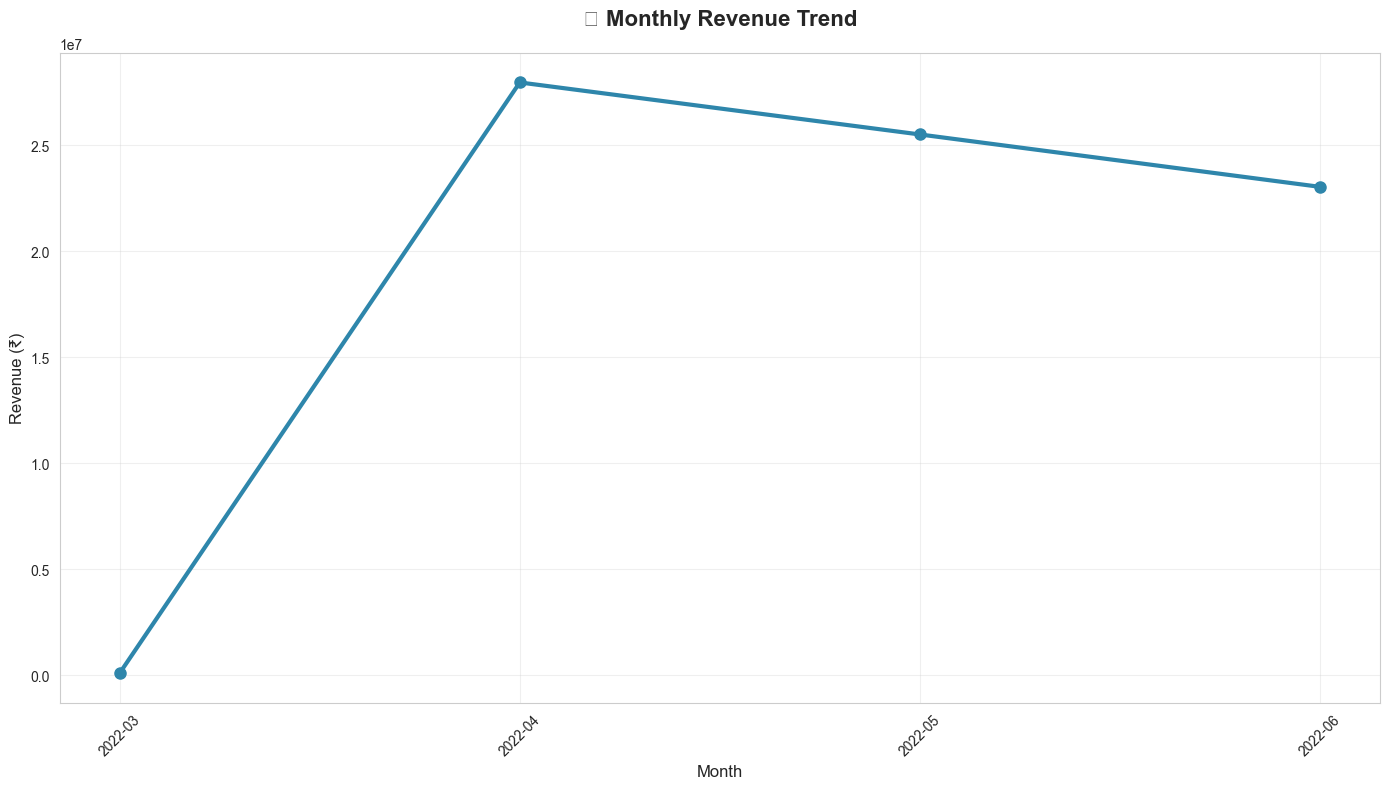

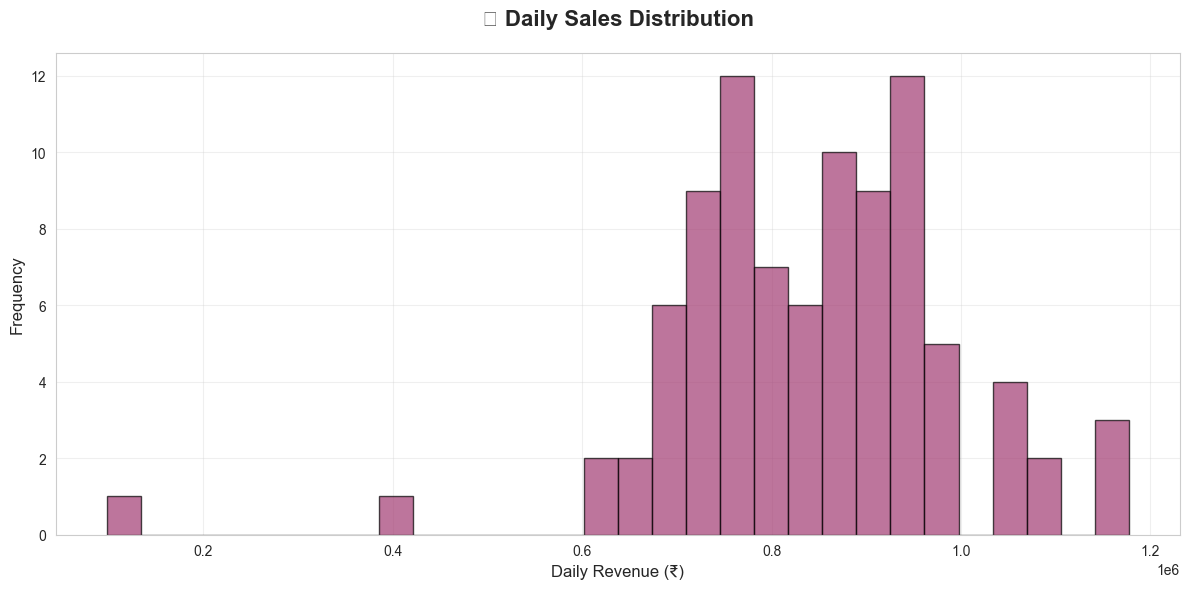

✅ Sales trend visualizations saved!
🛍️ CREATING CATEGORY PERFORMANCE VISUALIZATIONS...


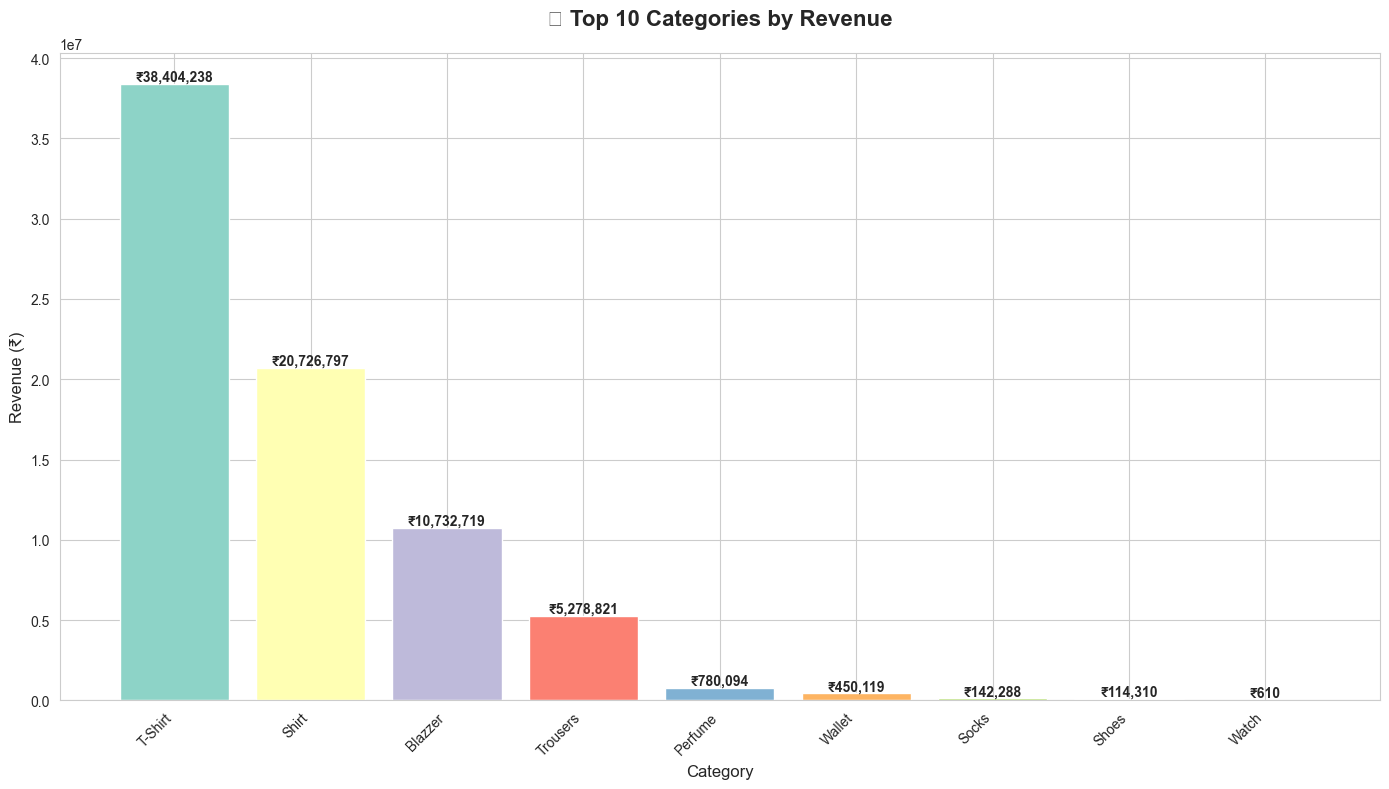

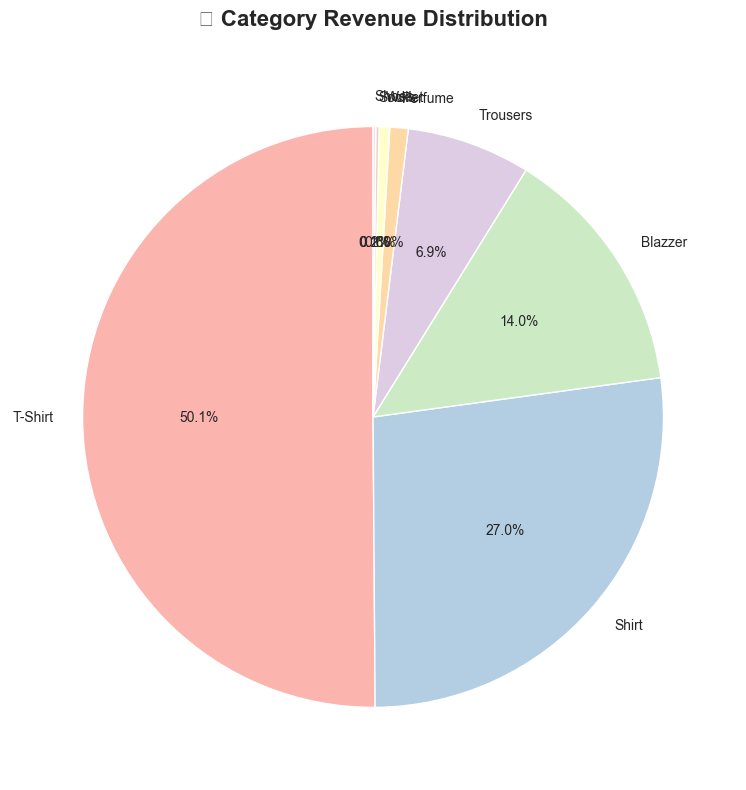

✅ Category visualizations saved!
🗺️ CREATING REGIONAL VISUALIZATIONS...


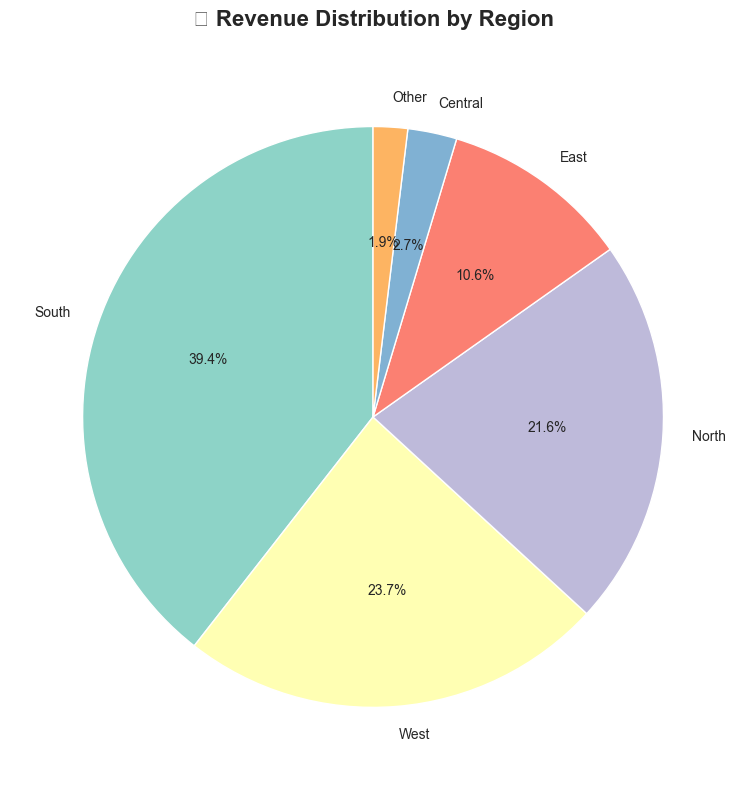

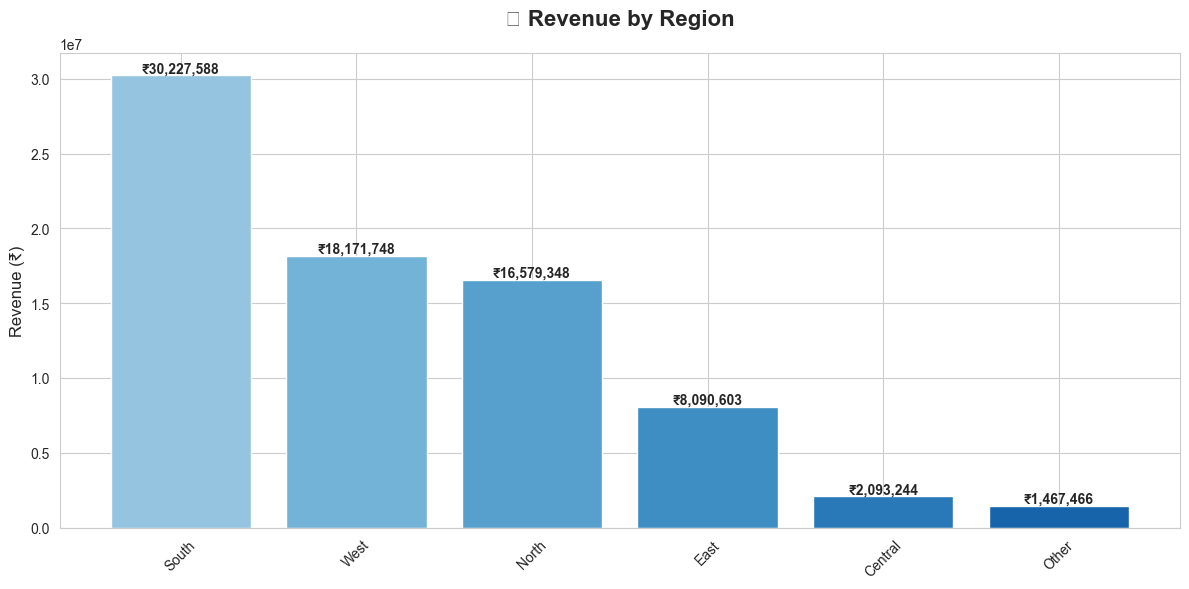

✅ Regional visualizations saved!
🚚 CREATING FULFILLMENT VISUALIZATIONS...


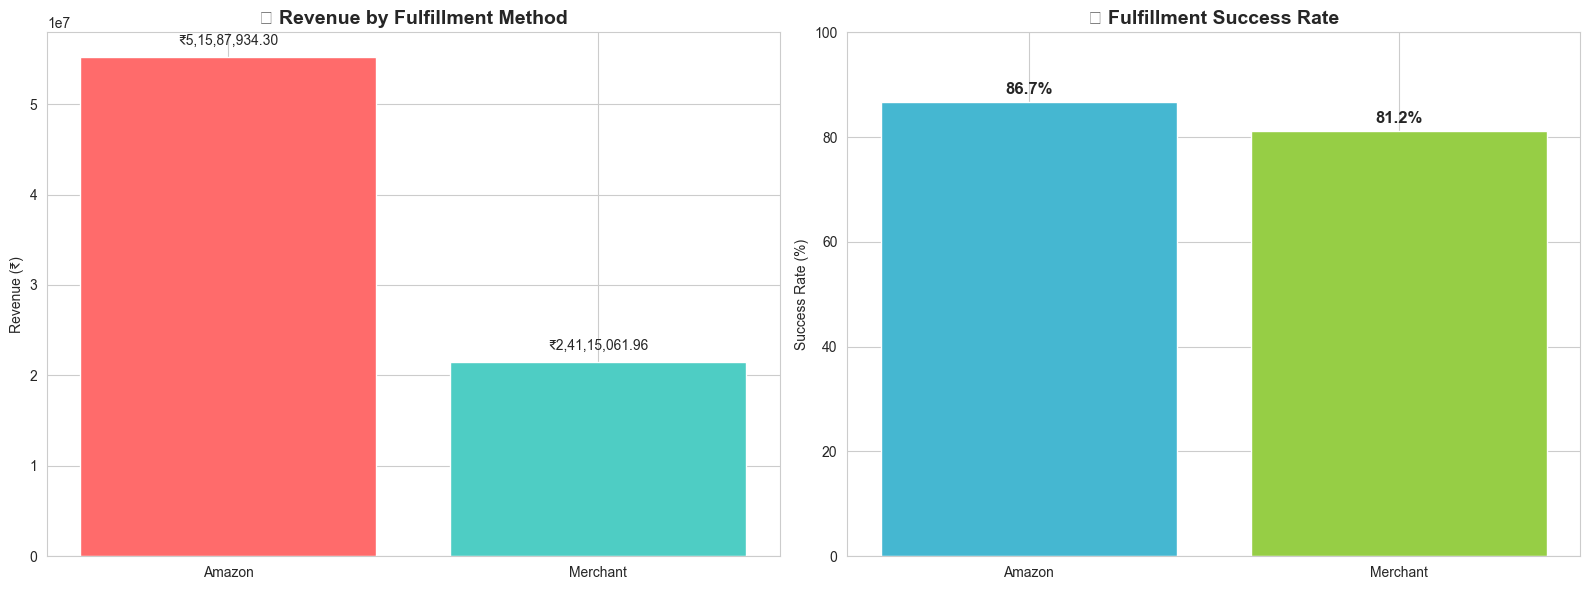

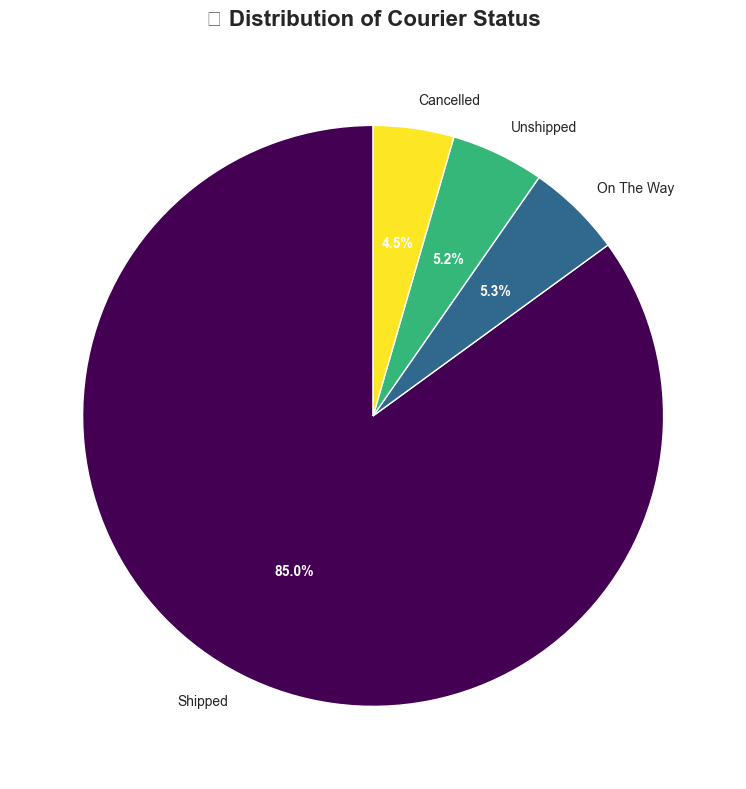

✅ Fulfillment visualizations saved!
🌤️ CREATING SEASONAL VISUALIZATIONS...


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


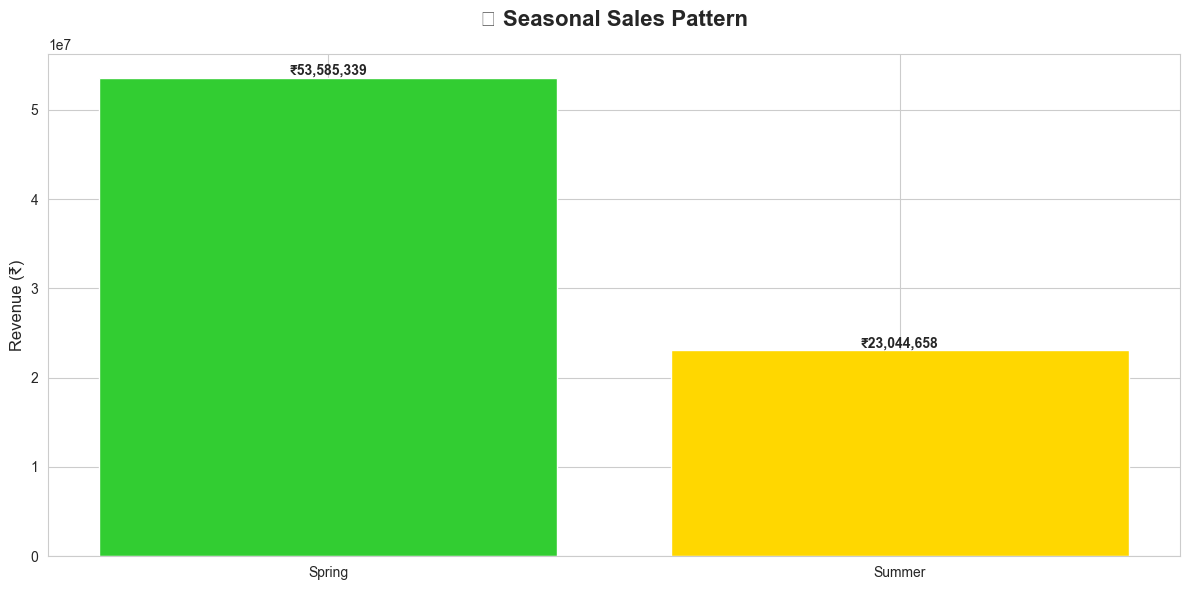

✅ Seasonal visualizations saved!
📊 CREATING COMPREHENSIVE DASHBOARD...


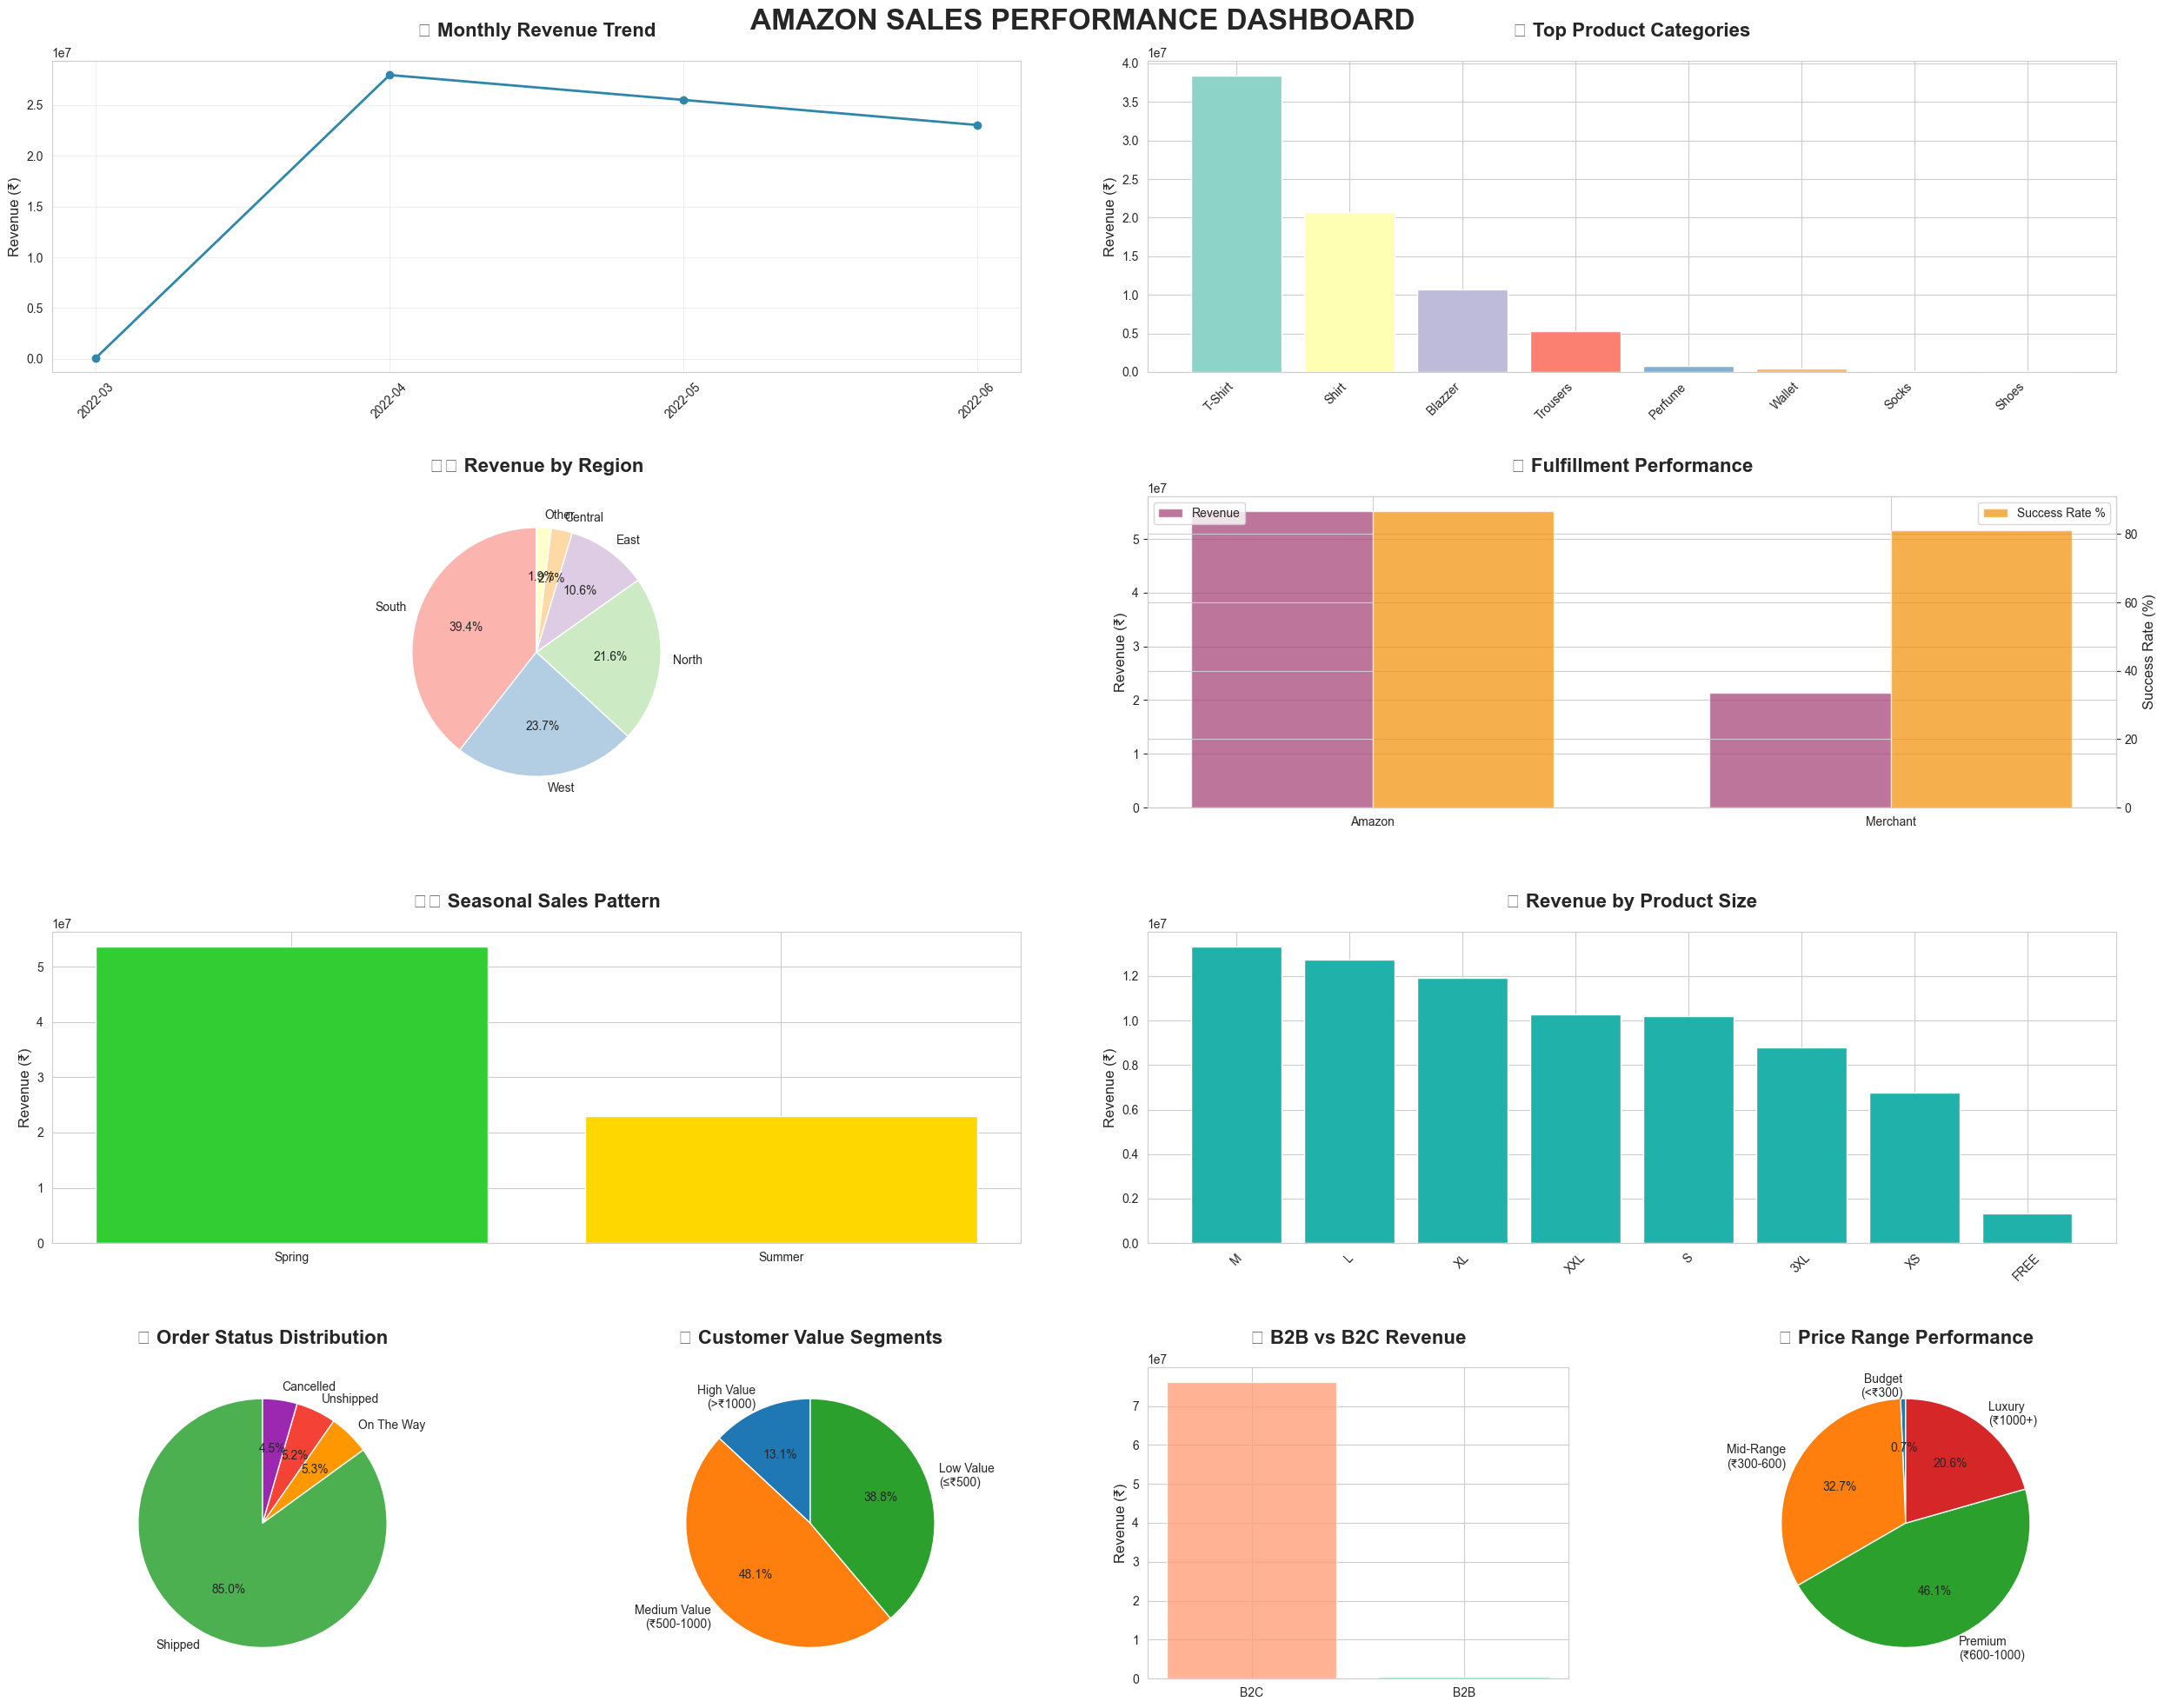

✅ Comprehensive dashboard saved!

📋 GENERATING EXECUTIVE REPORT...

🎯 EXECUTIVE SUMMARY
Analysis Period: 2022-03-31 to 2022-06-29
Total Revenue: ₹7,66,92,996.26
Total Orders: 1,82,017
Average Order Value: ₹598.59
Customer Reach: 7292 cities across 48 states
Order Success Rate: 85.0%

💡 KEY INSIGHTS
   1. 🎯 T-Shirt dominates with 50.1% of total revenue
   2. 🗺️ South region contributes 39.4% of sales
   3. 📈 Peak daily revenue reached ₹11,77,204.90
   4. 👥 Business serves 7292 cities nationwide
   5. ✅ Order fulfillment success rate: 85.0%
   6. 📦 115953 units sold across 9 product categories

🚀 STRATEGIC RECOMMENDATIONS
   1. 🎯 **PRODUCT FOCUS**: Double down on 'T-Shirt' category (50.1% of revenue)
   2. 🗺️ **MARKET EXPANSION**: Intensify marketing in South region (39.4% share)
   3. 📦 **INVENTORY OPTIMIZATION**: Monitor stock levels for top-performing sizes
   4. 👥 **CUSTOMER RETENTION**: Implement loyalty program for high-value customers
   5. 📊 **DATA-DRIVEN DECISIONS**: Use insight

In [118]:
if __name__ == "__main__":
    # Run the complete analysis
    final_results = run_comprehensive_analysis()

# Thank You....!